# Data Visualization

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

raw_data = pd.read_csv('./Datset/Customer-Churn-Records.csv')
df = raw_data.copy()
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

## Drop feature

In [15]:
drop_feature = ['Surname', 'RowNumber', 'CustomerId']
df = df.drop(drop_feature, axis=1)

df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction Score', 'Card Type',
       'Point Earned'],
      dtype='object')

## Distribution of Feature

In [31]:
numerical_col = df.select_dtypes(exclude='object').columns
categorical_col = df.select_dtypes(include='object').columns

print(numerical_col)
print('-'*90)
print(categorical_col)

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Point Earned'],
      dtype='object')
------------------------------------------------------------------------------------------
Index(['Geography', 'Gender', 'Card Type'], dtype='object')


In [ ]:
df['Point Earned'].describe()

count    10000.000000
mean       606.515100
std        225.924839
min        119.000000
25%        410.000000
50%        605.000000
75%        801.000000
max       1000.000000
Name: Point Earned, dtype: float64

<Axes: ylabel='Point Earned'>

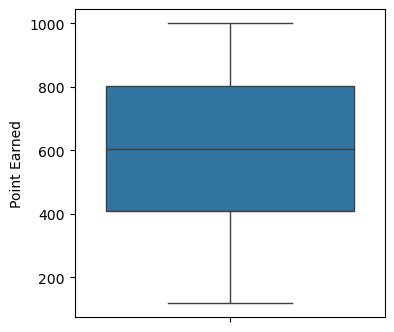

In [39]:
plt.figure(figsize=(4,4))
sns.boxplot(df['Point Earned'])

In [ ]:
df['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

<Axes: ylabel='CreditScore'>

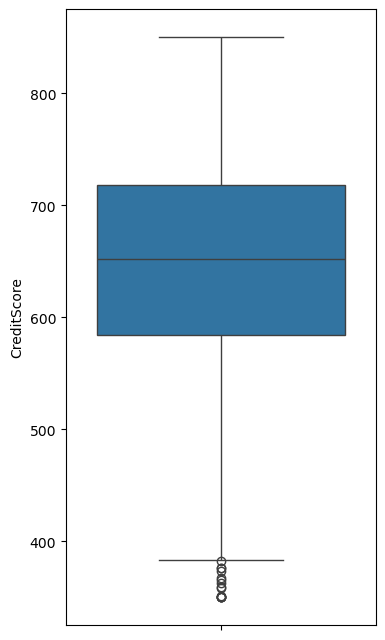

In [45]:
plt.figure(figsize=(4,8))
sns.boxplot(df['CreditScore'])

### Numerical Data

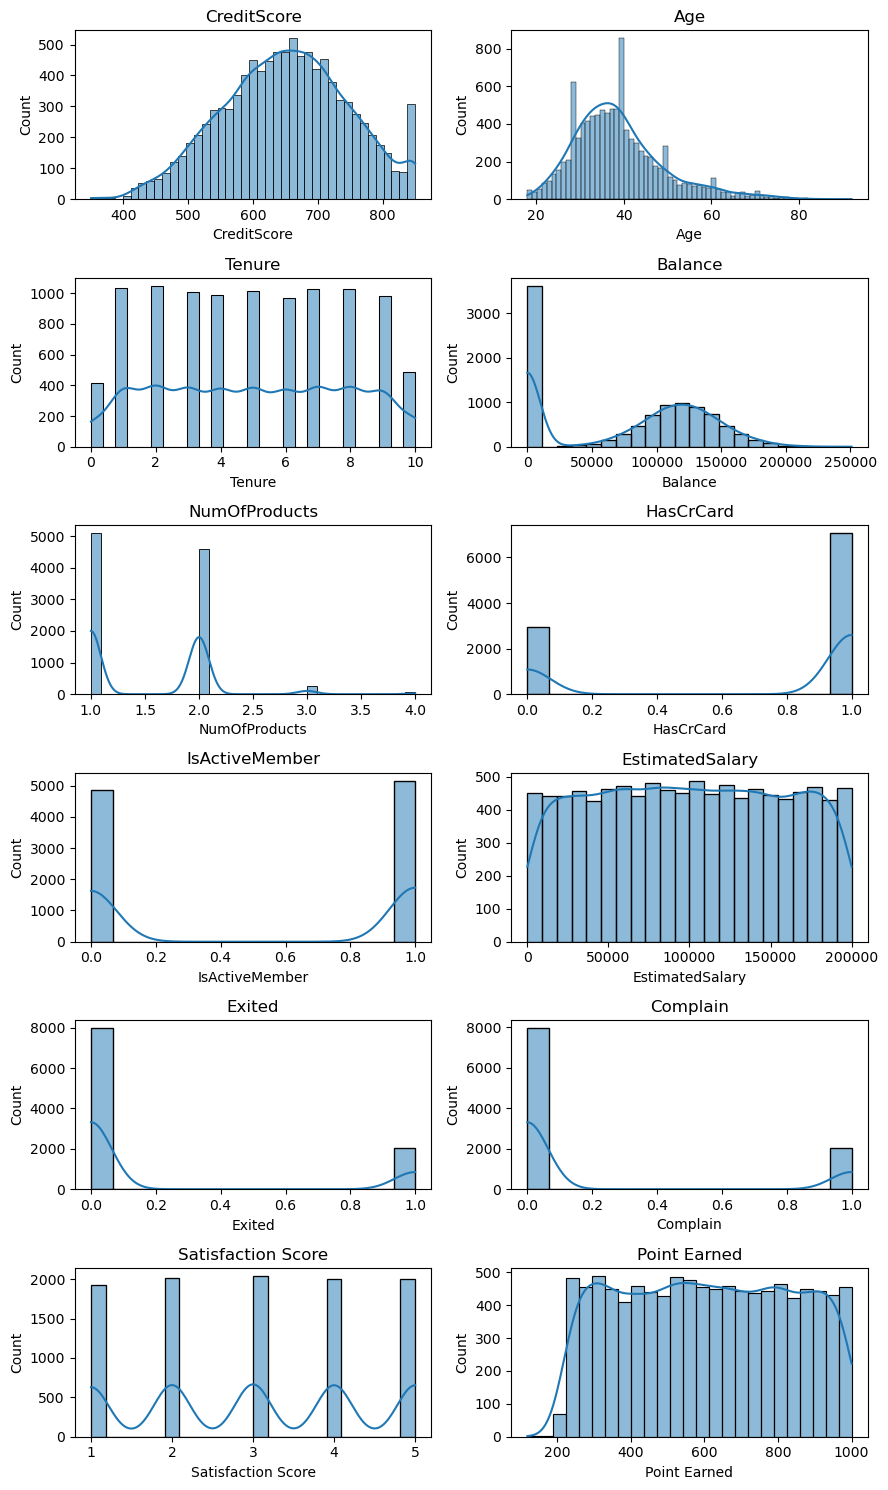

In [54]:
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=[9, 15])

for i, columns in enumerate(numerical_col):
    row, col = divmod(i, 2)
    sns.histplot(df[columns], ax=axes[row, col], kde=True)
    axes[row, col].set_title(columns)

plt.tight_layout()
plt.show()

### Categorical Data

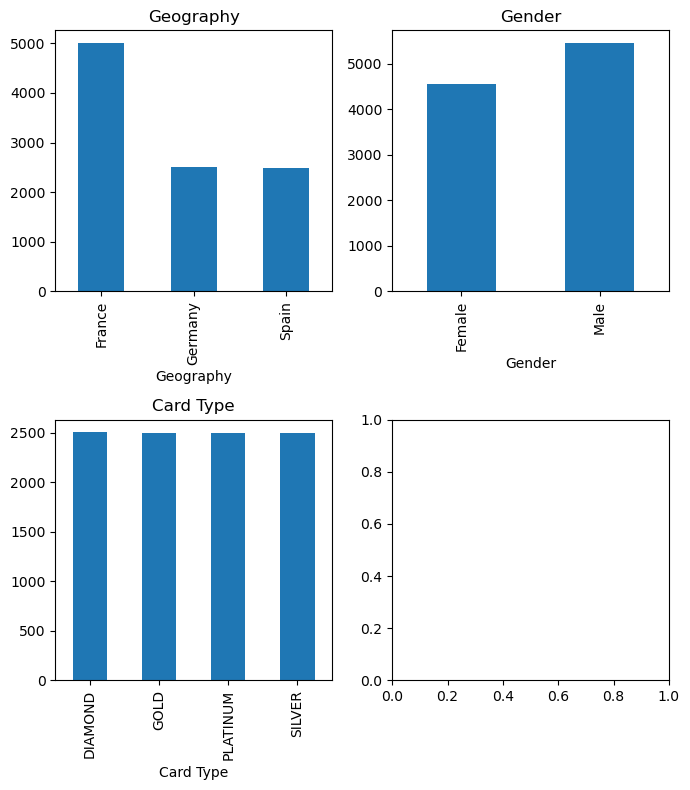

In [62]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=[7 ,8])
for i, column in enumerate(categorical_col):
    row, col = divmod(i, 2)
    df.groupby(column)[column].value_counts().plot(kind='bar', ax=axes[row, col])
    axes[row, col].set_title(column)
plt.tight_layout()
plt.show()

# Insight

## Data Correlation

In [ ]:
corr = df.corr(numeric_only=True)

<Axes: >

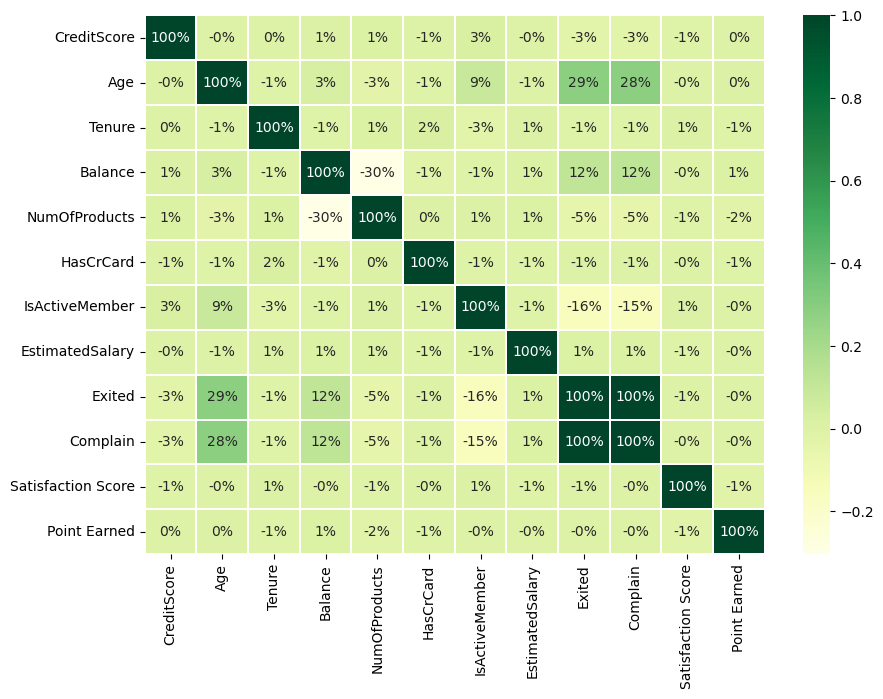

In [86]:
plt.figure(figsize=[10, 7])
sns.heatmap(df[numerical_col].corr(), cmap='YlGn', annot=True, fmt='.0%', lw=.2)

### Corralation of data
1. Age กับ Exited (29%) - ยิ่งอายุยิ่งเยอะ ยิ่งมีการเลิกใช้บริการมากกขึ้น
2. Complain กับ Exited (100%) - ยิ่งอายุยิ่งเยอะ ยิ่งมีการร้องเรียนเยอะขึ้น อาจจะด้วยเรื่องของการต้องการความมั่นคง

### 1. ช่วงอายุที่ Exited 

In [93]:
df['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

In [95]:
bins = [0, 20, 40, 60, 80]  # กำหนดช่วง
labels = ['>=20', '21-40', '41-60', '<=60']  # ชื่อช่วง
df['Binned-Age'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

In [97]:
df[['Age', 'Binned-Age']].head()

,Age,Binned-Age
0,42,41-60
1,41,41-60
2,42,41-60
3,39,21-40
4,43,41-60


In [99]:
insight_1 = df.groupby(['Binned-Age'])['Exited'].value_counts().unstack()
insight_1

Exited,0,1
Binned-Age,,
>=20,84,5
21-40,5648,682
41-60,1881,1236
<=60,338,114


<Figure size 400x300 with 0 Axes>

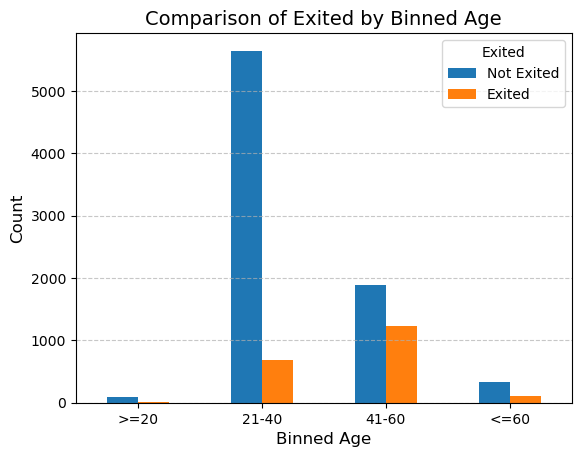

In [136]:
plt.figure(figsize=(4,3))
insight_1.plot(kind='bar')
plt.title("Comparison of Exited by Binned Age", fontsize=14)
plt.xlabel("Binned Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(["Not Exited", "Exited"], title="Exited")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

ช่วงอายุตั้งแต่ 41-60 ปี มีอัตราการเลิกใช้บริการมากที่สุด ลูกค้าในช่วงอายุนี้เริ่มวางแผน เกษียณอายุ และอาจย้ายสินทรัพย์ไปยังธนาคารหรือสถาบันการเงินที่ให้ผลตอบแทนดีกว่า ซึ่งคาดหวังบริการที่เป็นส่วนตัวมากขึ้น ถ้าธนาคารไม่สามารถตอบสนองความต้องการได้ เช่น ให้คำปรึกษาทางการเงินที่ดี หรือเสนอผลิตภัณฑ์ที่ตรงกับไลฟ์สไตล์

### 2. จำนวน Exited ในแต่ละ ประเทศ แยกชายหญิง

In [110]:
insight_2 = df.groupby(['Geography', 'Gender', 'Exited'])['Exited'].count().unstack()
insight_2

Exited               0    1
Geography Gender           
France    Female  1801  460
          Male    2402  351
Germany   Female   745  448
          Male     950  366
Spain     Female   858  231
          Male    1206  182

<Figure size 400x300 with 0 Axes>

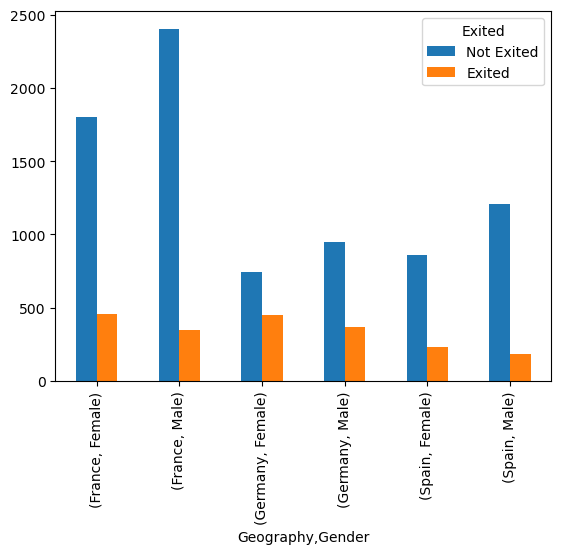

In [116]:
plt.figure(figsize=(4,3))
insight_2.plot(kind='bar')
plt.legend(["Not Exited", "Exited"], title="Exited")
plt.show()

churn rate จำแนกตาม เพศ และ ประเทศ จะเห็นว่าผู้หญิงมีแนวโน้มการเลิกใช้บริการมากกว่า และฝรั่งเศสเป็นอันดับหนึ่งของการไม่เลิกใช้บริการ 
Strategies : อาจแนะนำผลิตภัณฑ์ทางการเงินที่เหมาะกับพฤติกรรมการใช้จ่ายของลูกค้าผู้หญิง หรือบัตรเครดิตที่ให้รางวัลตรงกลุ่มเป้าหมาย เช่น ส่วนลดช้อปปิ้ง ร้านอาหาร หรือสะสมแต้มแลกของใช้จำเป็น

### 3. อัตราของ Exited

In [125]:
insight_3 = df['Exited'].value_counts()

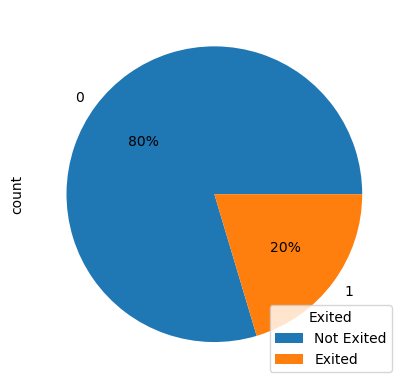

In [133]:
insight_3.plot(kind='pie', autopct='%1.0f%%')
plt.legend(["Not Exited", "Exited"], title="Exited", loc='best')

pie chart อัตราส่วนของ ลูกค้าที่เลิกใช้ละลูกค้าที่ยังใช้บริการอยู่กับธนาคาร จะเห็นว่าข้อมูลมีความ imbalance สูง 

### 4. ประเทศ กับ card type ว่ามีส่วนใดถือมากที่สุด และดูคน Exited

In [145]:
insight_4 = df.groupby(['Geography', 'Card Type', 'Exited'])['Exited'].count().unstack()
insight_4

Exited                  0    1
Geography Card Type           
France    DIAMOND    1009  221
          GOLD       1045  190
          PLATINUM   1070  194
          SILVER     1079  206
Germany   DIAMOND     428  220
          GOLD        452  201
          PLATINUM    403  205
          SILVER      412  188
Spain     DIAMOND     524  105
          GOLD        523   91
          PLATINUM    514  109
          SILVER      503  108

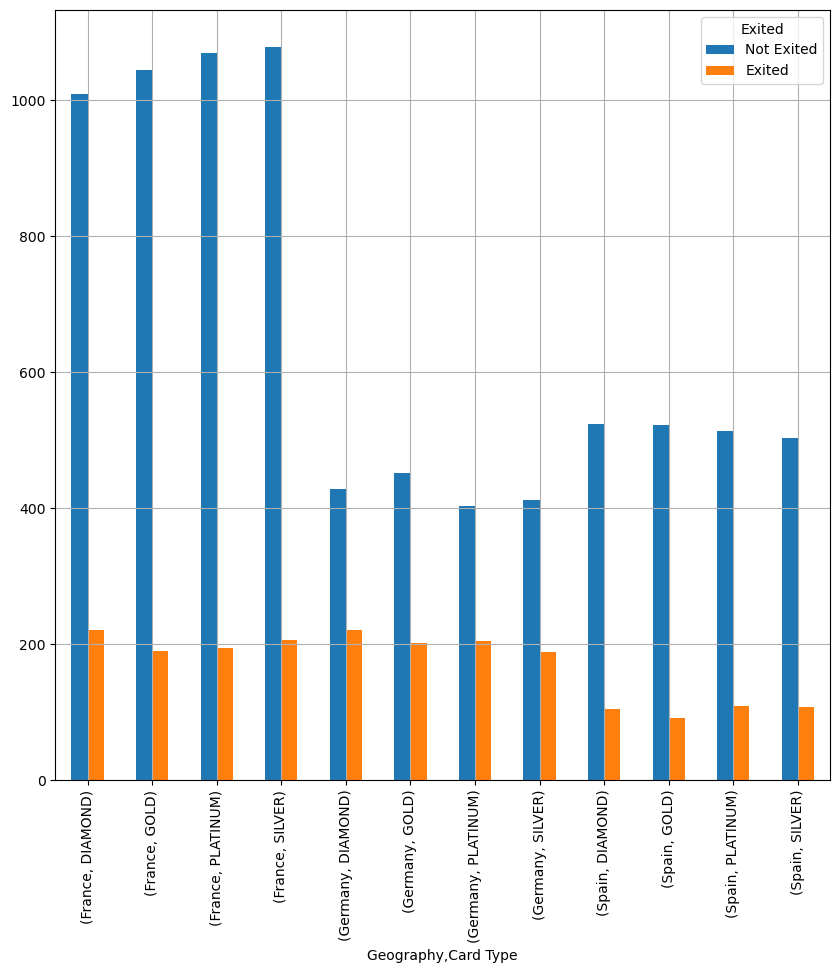

In [149]:
insight_4.plot(kind='bar', figsize=[10, 10], grid=True)
plt.legend(["Not Exited", "Exited"], title="Exited", loc='best')
plt.show()

ผู้ถือบัตร Diamond มักเป็นลูกค้าระดับ high-end ที่มีการเงินสูง อาจทำให้เปลี่ยนใจไปใช้ธนาคารที่ให้ข้อเสนอที่ดีกว่าลูกค้ารายอื่นได้ง่ายกว่า และลูกค้าบัตร Diamond อาจรู้สึกว่าสิทธิพิเศษที่ได้รับไม่คุ้มกับค่าธรรมเนียมบัตร หรือการบริการนั่นเอง

### 5. Balance กับ NumOfProducts

In [162]:
insight_5 = df.groupby(['NumOfProducts'])['Balance'].mean()
df['NumOfProducts']

0       1
1       1
2       3
3       2
4       1
       ..
9995    2
9996    1
9997    1
9998    2
9999    1
Name: NumOfProducts, Length: 10000, dtype: int64

In [164]:
df['NumOfProducts'].unique()

array([1, 3, 2, 4], dtype=int64)

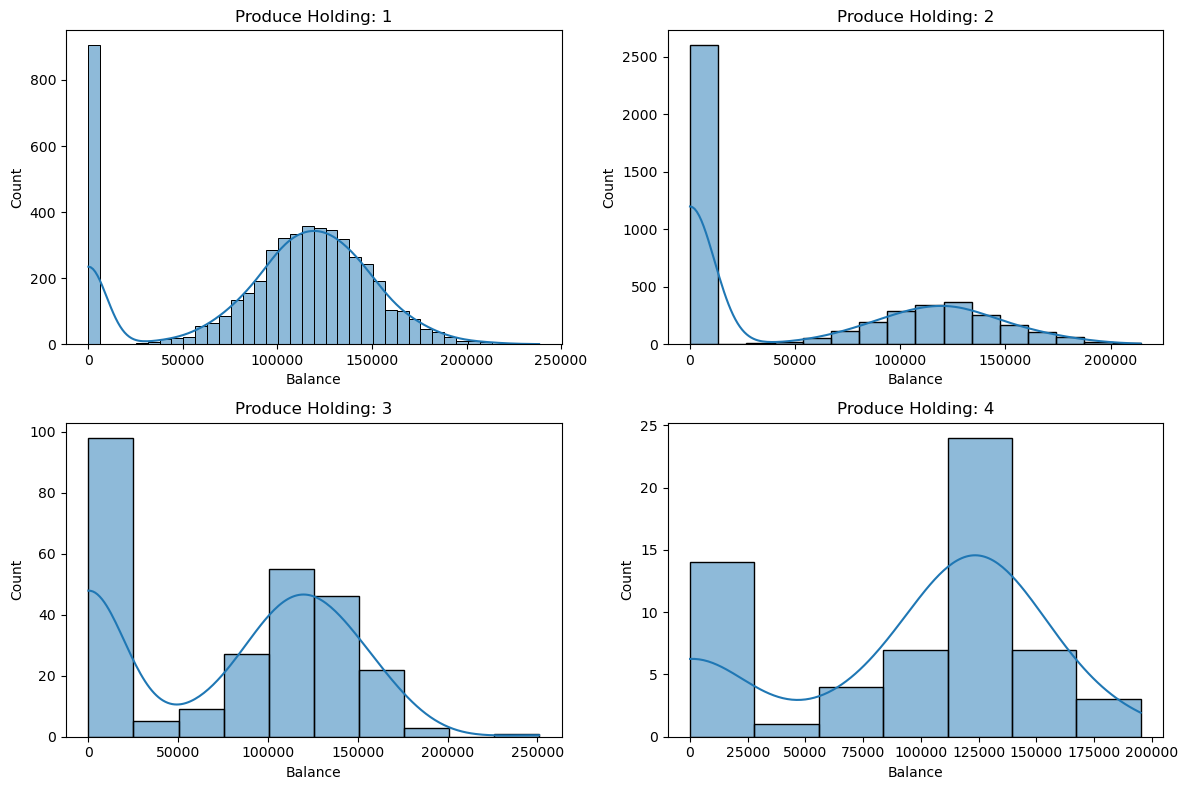

In [184]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=[12, 8])

for i, column in zip(np.arange(0, 4), np.arange(0, 4)):
    row, col = divmod(i, 2)
    sns.histplot(df['Balance'][df['NumOfProducts'] == i+1], ax=axes[row, col], kde=True)
    axes[row, col].set_title(f'Produce Holding: {i+1}')
    
plt.tight_layout()
plt.show()

1. กลุ่มที่ 1 มี Balance สูงมาก มีแนวโน้มเป็นกลุ่มที่มีความมั่นคงทางการเงิน แต่อาจไม่ใช่ลูกค้าที่ loyalty ต่อธนาคาร อาจเป็นกลุ่มที่กำลังมองหาดอกเบี้ยสูงจากธนาคารอื่น
2. กลุ่มที่ 2 มียอดเงินคงเหลือน้อย อาจสะท้อนถึงพฤติกรรมการใช้วงเงินมาก ลูกค้ากลุ่มนี้อาจเป็นกลุ่มที่มี หนี้สินสูง หรือเป็นกลุ่มที่ใช้ผลิตภัณฑ์ของหลายธนาคาร
3. กลุ่มที่ 3 อาจเป็นกลุ่มลูกค้าที่ใช้ทั้ง บัญชีเงินฝาก บัตรเครดิต และสินเชื่อบางประเภท มีความสัมพันธ์ที่ค่อนข้างดีกับธนาคาร หากธนาคารไม่มีข้อเสนอที่คุ้มค่าอาจเปลี่ยนไปใช้บริการจากคู่แข่ง
4. กลุ่มที่ 4 เป็นลูกค้าที่ใช้บริการธนาคารแบบครบวงจร มักเป็นลูกค้าระดับ High-Value ที่ธนาคารต้องการรักษาไว้ แต่หากธนาคารอื่นเสนอผลิตภัณฑ์ที่ดีกว่า อาจดึงดูดให้ย้ายไปใช้บริการ

### 6. ดู Tenure เทียบกับ Exited

In [190]:
insight_6 = df.groupby(['Tenure', 'Exited'])['Exited'].value_counts().unstack()
insight_6

Exited,0,1
Tenure,,
0,318,95
1,803,232
2,847,201
3,796,213
4,786,203
5,803,209
6,771,196
7,851,177
8,828,197


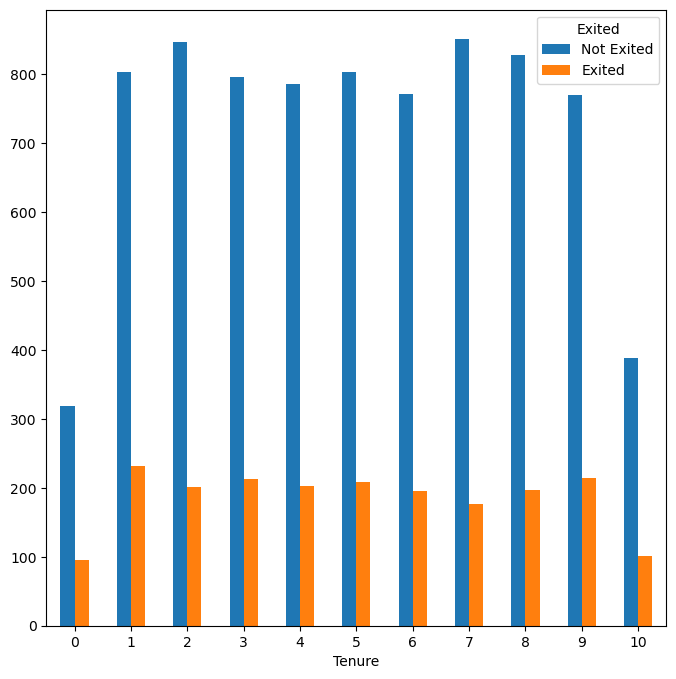

In [192]:
insight_6.plot(kind='bar', figsize=[8, 8])
plt.legend(["Not Exited", "Exited"], title="Exited")
plt.xticks(rotation=0)
plt.show()

1. ลูกค้าที่อยู่ไม่นาน (0-1 ปี) มีอัตรา Churn สูงสุด : อาจเกิดจากลูกค้าใหม่ยังไม่มี Engagement กับธนาคาร หรือพบปัญหา เช่น ค่าธรรมเนียม บริการไม่ตรงใจ อาจเพิ่มโปรโมชันสำหรับลูกค้าใหม่ เช่น ต้องดอกเบี้ยพิเศษ, ค่าธรรมเนียมต่ำ, Rewards Program และฝ่าย Customer Service ต้องตอบสนองเร็วขึ้นเพื่อรักษากลุ่มนี้ให้ทัน

2. Churn ค่อย ๆ ลดลงในช่วง 2-7 ปี หลังจาก 1 ปี จำนวนลูกค้าที่ Churn ลดลงทีละน้อยแต่ churn ก็ยังคงที่ราวๆนี้  ลูกค้าที่ยังอยู่มักเป็นกลุ่มที่มี Loyalty สูงขึ้นและมี Engagement กับธนาคาร การรักษาลูกค้าในกลุ่มนี้อาจเสนอ Cross-Selling เช่น บัตรเครดิต, ประกัน หรือสินเชื่อเพื่อให้ลูกค้าใช้บริการหลายอย่างและลดโอกาส Churn

3. Churn เพิ่มขึ้นอีกครั้งในช่วง 8-9 ปี อาจเป็นเพราะ ลูกค้าเก่าเริ่มมองหาทางเลือกอื่น เช่น ธนาคารที่ให้ดอกเบี้ยดีกว่า หรือบริการที่สะดวกกว่า การรักษาลูกค้าในกลุ่มนี้อาจ ทำ Retention Program ให้ลูกค้ารู้สึกมีคุณค่า เช่น Exclusive Benefits หรือ VIP Services หรือ Survey เพื่อเข้าใจปัญหาที่ลูกค้าอาจมีและแก้ไขก่อนที่จะ Churn

4. ลูกค้าที่อยู่เกิน 10 ปี Churn ลดลง ลูกค้าที่อยู่ได้นานเกิน 10 ปี มักจะเป็นกลุ่มที่มี Loyalty สูงมาก และอาจใช้บริการหลายผลิตภัณฑ์ของธนาคาร หากต้องการลด Churn ควรโฟกัสที่ลูกค้าใหม่เป็นอันดับแรก และค่อยปรับกลยุทธ์สำหรับลูกค้าระยะยาว

## ข้อ 7-10 อาจไม่มีผลกับการพิจาณามาก

### 7. อัตราคน Exited เทียบกับ Satisfaction Score

In [196]:
insight_8 = df.groupby(['Satisfaction Score', 'Exited'])['Exited'].count().unstack()
insight_8

Exited,0,1
Satisfaction Score,,
1,1545,387
2,1575,439
3,1641,401
4,1594,414
5,1607,397


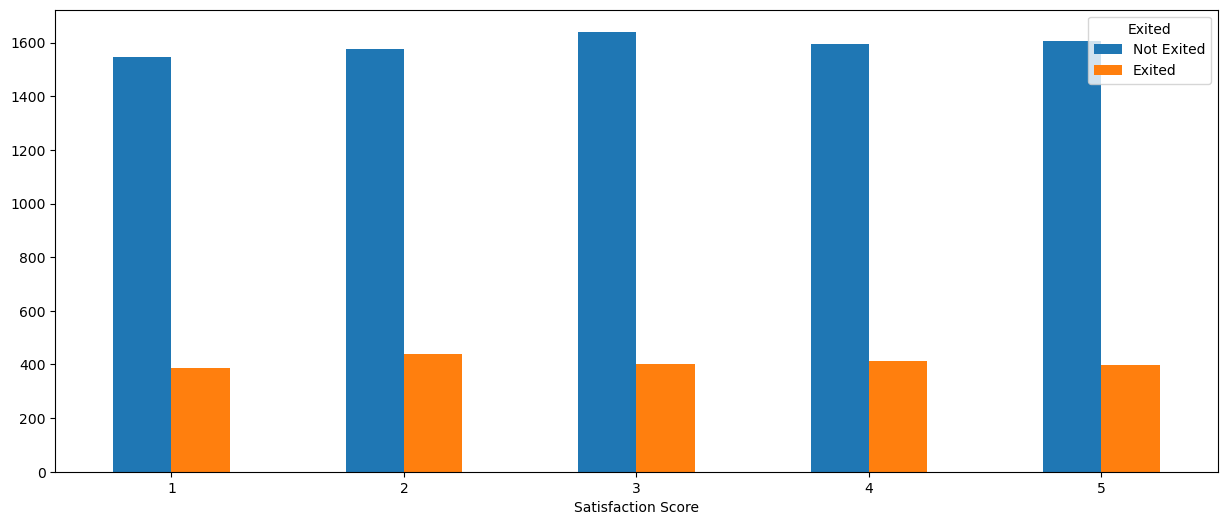

In [198]:
insight_8.plot(kind='bar', figsize=[15, 6])
plt.legend(["Not Exited", "Exited"], title="Exited")
plt.xticks(rotation=0)
plt.show()

### 8. Balance เทียบกับ ประเภทบัตร

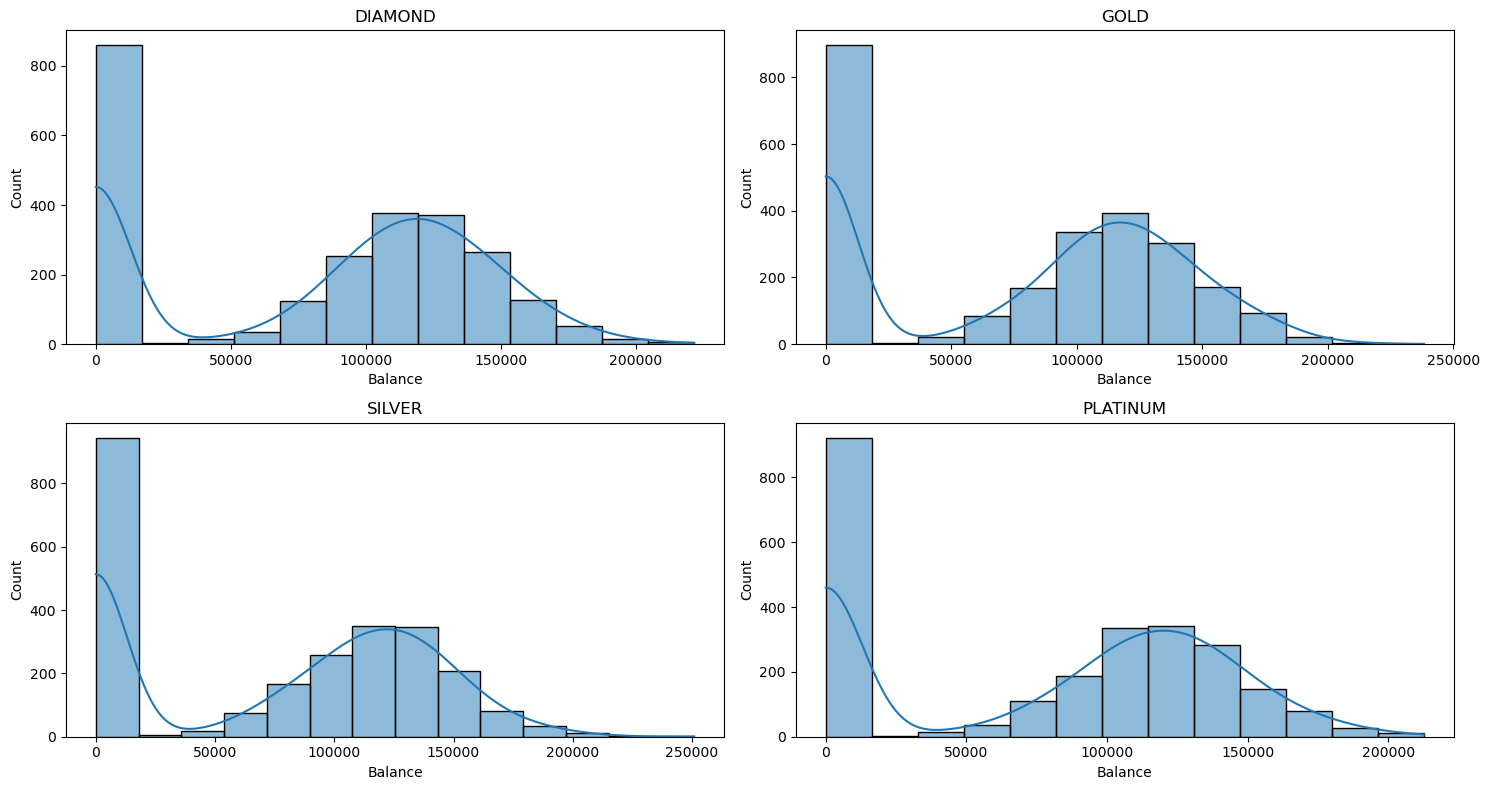

In [207]:
fig, axes = plt.subplots(nrows=2,
                         ncols=2,
                         figsize=[15, 8])
for i, column in enumerate(df['Card Type'].unique()):
    row, col = divmod(i, 2)
    sns.histplot(df['Balance'][df['Card Type'] == column], ax=axes[row, col], kde=True)
    axes[row, col].set_title(f'{column}')
    
plt.tight_layout()
plt.show()

### 9. เงินเดือน เทียบกับ ประเภทการ์ด

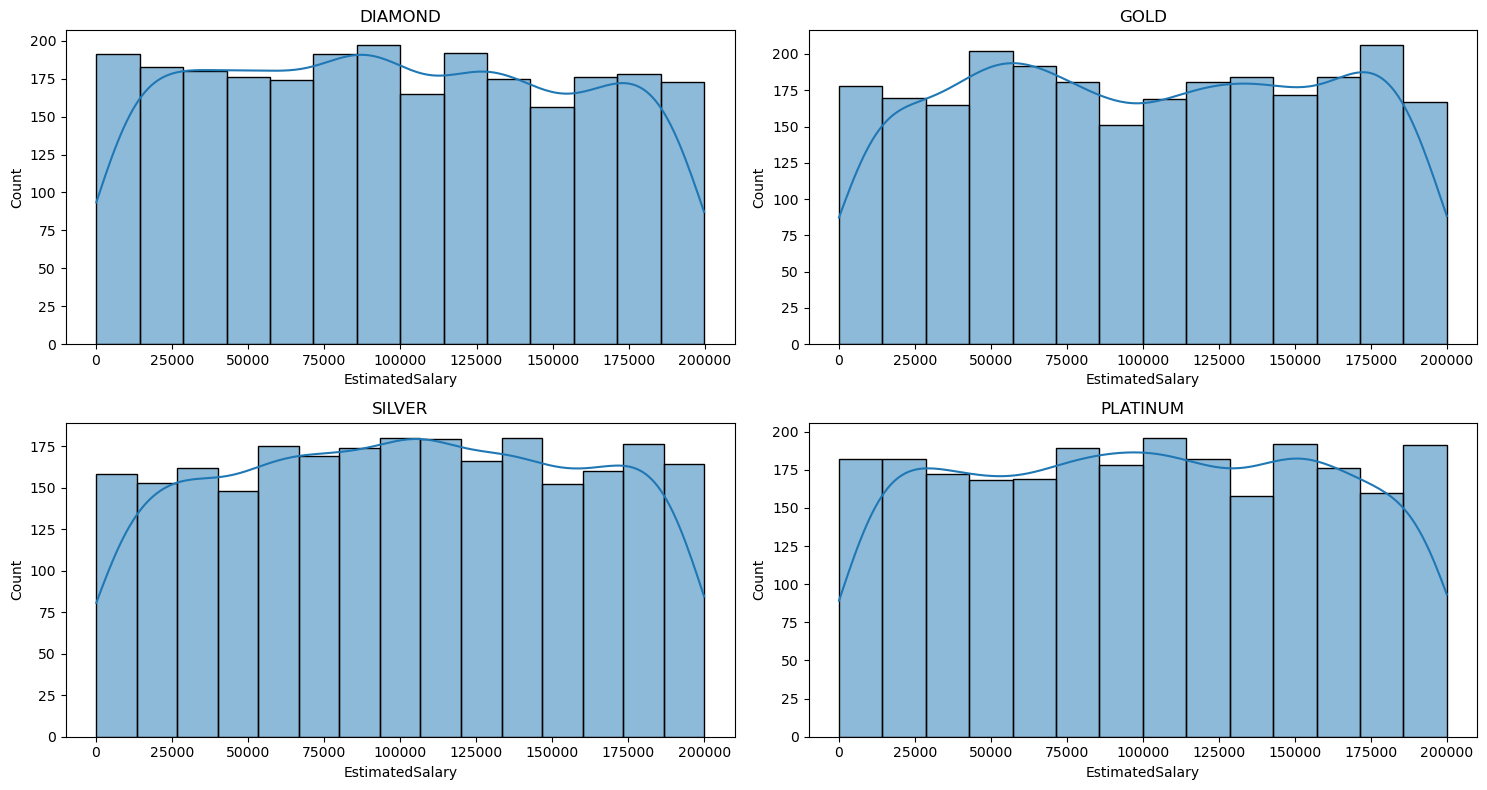

In [210]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=[15, 8])

for i, column in enumerate(df['Card Type'].unique()):
    row, col = divmod(i, 2)
    sns.histplot(df['EstimatedSalary'][df['Card Type'] == column], ax=axes[row, col], kde=True)
    axes[row, col].set_title(f'{column}')
    
plt.tight_layout()
plt.show()

### 10. CreditScore เทียบกับ ประเภทการ์ด

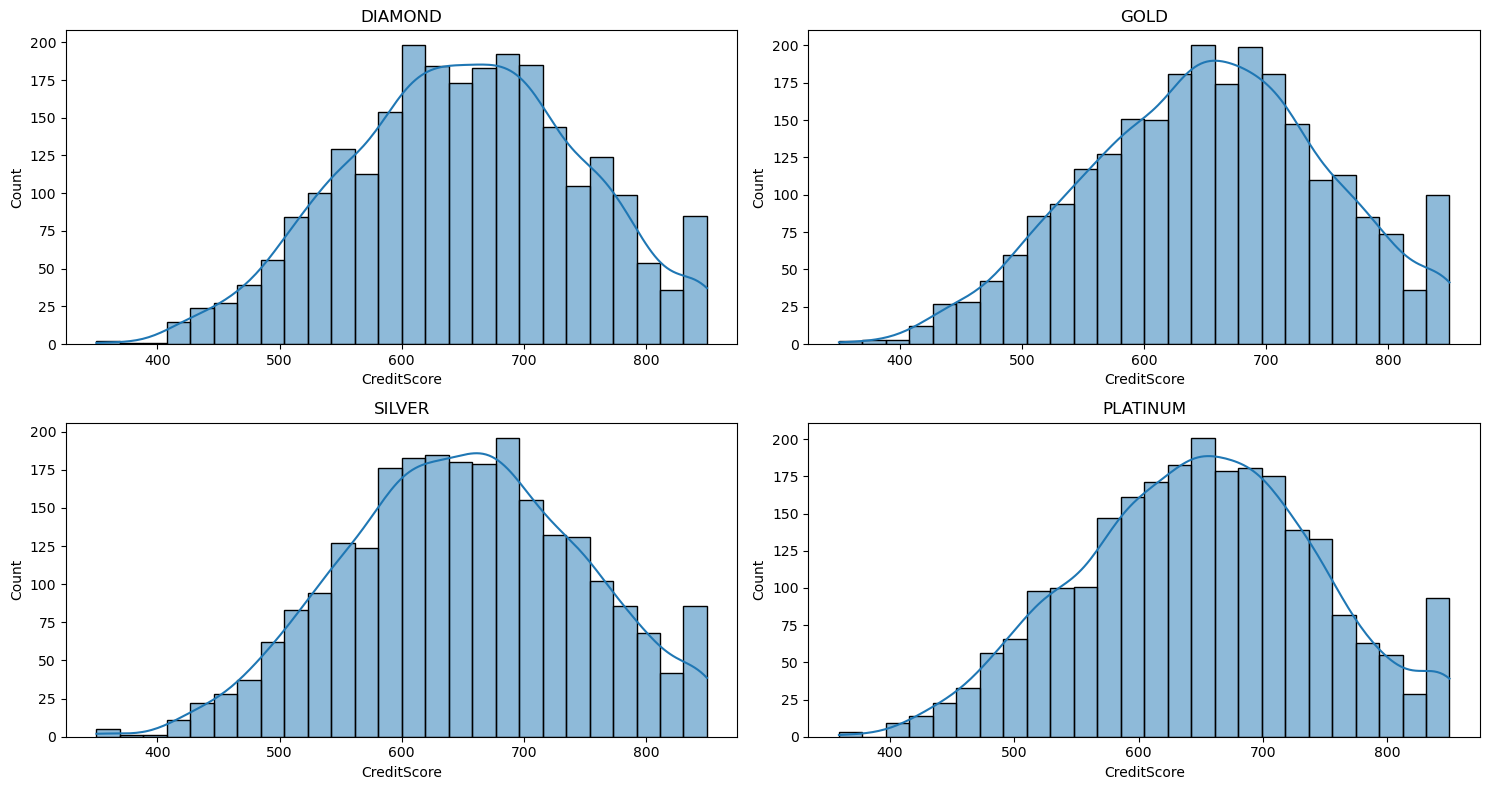

In [213]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=[15, 8])

for i, column in enumerate(df['Card Type'].unique()):
    row, col = divmod(i, 2)
    sns.histplot(df['CreditScore'][df['Card Type'] == column], ax=axes[row, col], kde=True)
    axes[row, col].set_title(f'{column}')
    
plt.tight_layout()
plt.show()